# Inferencia y Comparación del Modelo Earthformer en Local

Se ejecutó el modelo **Earthformer** instanciado a partir del código local en `earthformer_training_lab`. Se cargan los pesos del checkpoint de 160 MB y se realiza una comparación cuantitativa y visual de las predicciones de Earthformer frente a la **Persistencia** en las 5 muestras del dataset de IDEAM.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.data import (
    SAMPLE_FILES,
    LEAD_MINUTES,
    get_paths,
    load_sample,
    split_sequence,
    load_prediction,
    make_persistence_prediction,
)
from course_utils.palette import apply_course_style, RAIN_LEVELS
from course_utils.metrics import continuous_metrics, event_metrics_by_threshold_and_lead

apply_course_style()
paths = get_paths(PROJECT_ROOT)
print(f"Proyecto: {paths.root}")

Proyecto: C:\Users\Pedro Lopevia\Escritorio\S04-nowcasting-course-lab


## 1. Instanciar y Cargar Pesos de Earthformer Local

Usamos el archivo local `earthformer_training_lab.model.build_earthformer` para instanciar el modelo de manera nativa sin recurrir a dependencias externas, y cargamos el state_dict desde el checkpoint de 160 MB.

In [3]:
from earthformer_training_lab.model import build_earthformer

# 1. Instanciar usando el YAML de configuración local
config_yaml = PROJECT_ROOT / "earthformer_training_lab" / "config" / "earthformer_ideam_course.yaml"
model = build_earthformer(config_yaml)

# 2. Cargar pesos desde el checkpoint local
checkpoint_path = PROJECT_ROOT / "checkpoints" / "ef_ideam_final" / "ef_ckpt.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(checkpoint["model"]["EarthFormer_xy"])
model.eval()
print("Earthformer local instanciado y cargado correctamente.")

Earthformer local instanciado y cargado correctamente.


## 2. Inferencia sobre las Muestras de IDEAM

Corremos el modelo sobre cada una de las 5 muestras del IDEAM y recolectamos las predicciones de Earthformer, comparándolas con la Persistencia y el Target real.

In [4]:
MAX_RAIN = 60.0
INPUT_FRAMES = 13
PRED_FRAMES = 12

def run_local_earthformer_inference(sample_name):
    # Cargar datos
    sequence = load_sample(sample_name, paths)
    inputs, target = split_sequence(sequence)
    
    # Persistencia
    persistence = make_persistence_prediction(inputs)
    
    # Inferencia Earthformer
    with torch.no_grad():
        x = torch.from_numpy(inputs[None, :, None]).float()  # (B=1, T=13, C=1, H, W)
        x_norm = torch.clamp(x, 0.0, MAX_RAIN) / MAX_RAIN
        pred_norm = model(x_norm)  # (1, 12, 1, 128, 128)
        pred_norm = torch.clamp(pred_norm, 0.0, 1.0)
        earthformer = (pred_norm[0, :, 0] * MAX_RAIN).numpy().astype(np.float32)
        
    return inputs, target, persistence, earthformer

In [5]:
all_results = {}
rows = []
THRESHOLDS = [0.5, 2.0, 5.0, 10.0]

for name in SAMPLE_FILES:
    inputs, target, persistence, earthformer = run_local_earthformer_inference(name)
    all_results[name] = {
        "inputs": inputs,
        "target": target,
        "persistence": persistence,
        "earthformer": earthformer
    }
    
    # Calcular métricas para persistencia y earthformer
    for label, pred in [("persistence", persistence), ("earthformer", earthformer)]:
        c_df = continuous_metrics(pred, target)
        e_df = event_metrics_by_threshold_and_lead(pred, target, THRESHOLDS)
        rows.append({
            "sample": name,
            "model": label,
            "RMSE_mean": float(c_df["RMSE"].mean()),
            "MAE_mean": float(c_df["MAE"].mean()),
            "Bias_mean": float(c_df["Bias"].mean()),
            "Pearson_mean": float(c_df["Pearson_r"].mean()),
            "CSI_0.5_mean": float(e_df[e_df["threshold_mm_h"] == 0.5]["CSI"].mean()),
            "CSI_5_mean": float(e_df[e_df["threshold_mm_h"] == 5.0]["CSI"].mean()),
            "CSI_10_mean": float(e_df[e_df["threshold_mm_h"] == 10.0]["CSI"].mean()),
        })

metrics_df = pd.DataFrame(rows)
overall_df = metrics_df.groupby("model").mean(numeric_only=True)
overall_df

,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_5_mean,CSI_10_mean
model,,,,,,,
earthformer,1.086632,0.347085,0.011699,0.577228,0.590705,0.099062,0.089423
persistence,1.717438,0.449517,0.056092,0.376623,0.544273,0.100940,0.074848


## 3. Visualización de Predicciones y Métricas

Graficamos la evolución espacial de un caso y luego comparamos el comportamiento temporal de RMSE y CSI.

Comparación visual para barranca_seq_20240426_2000_patch_04_rain_rate.npy (Persistencia vs Earthformer)


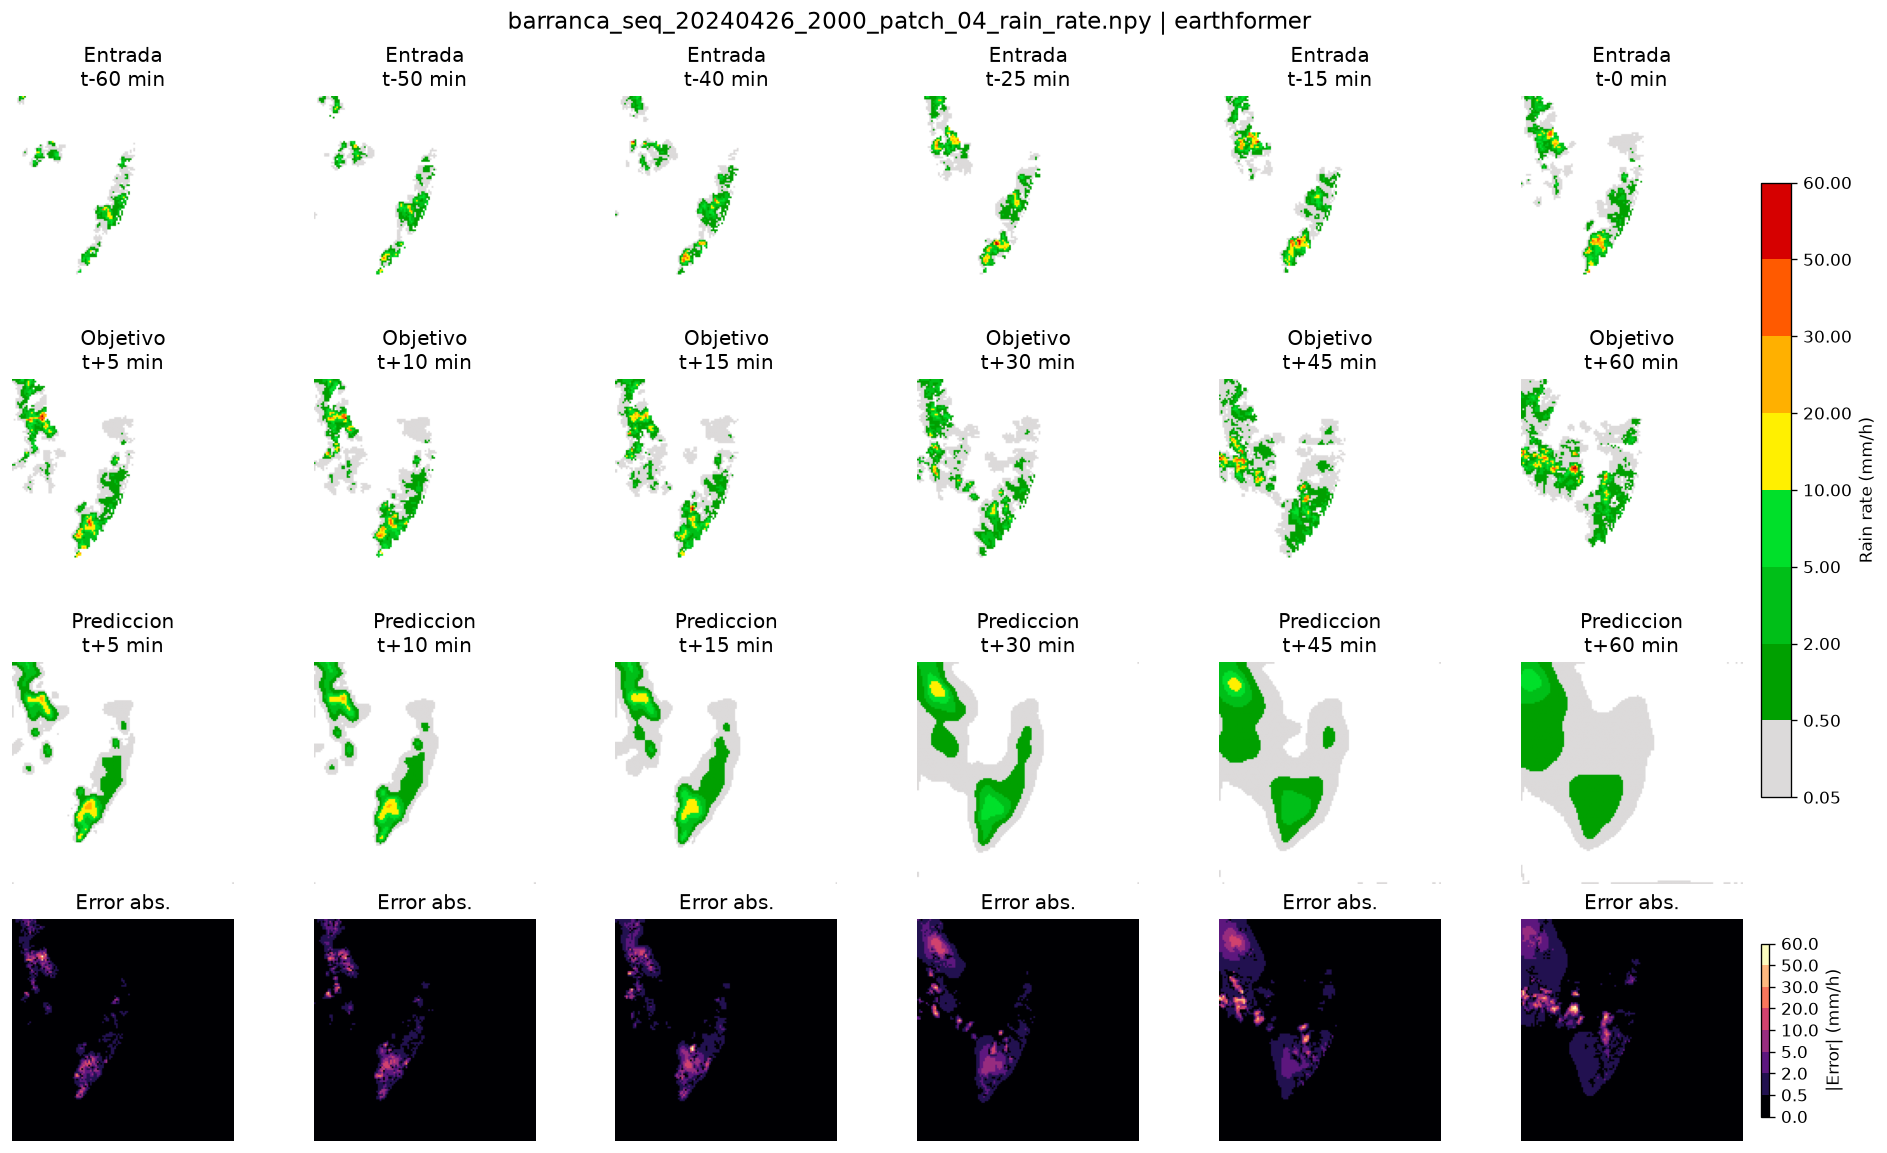

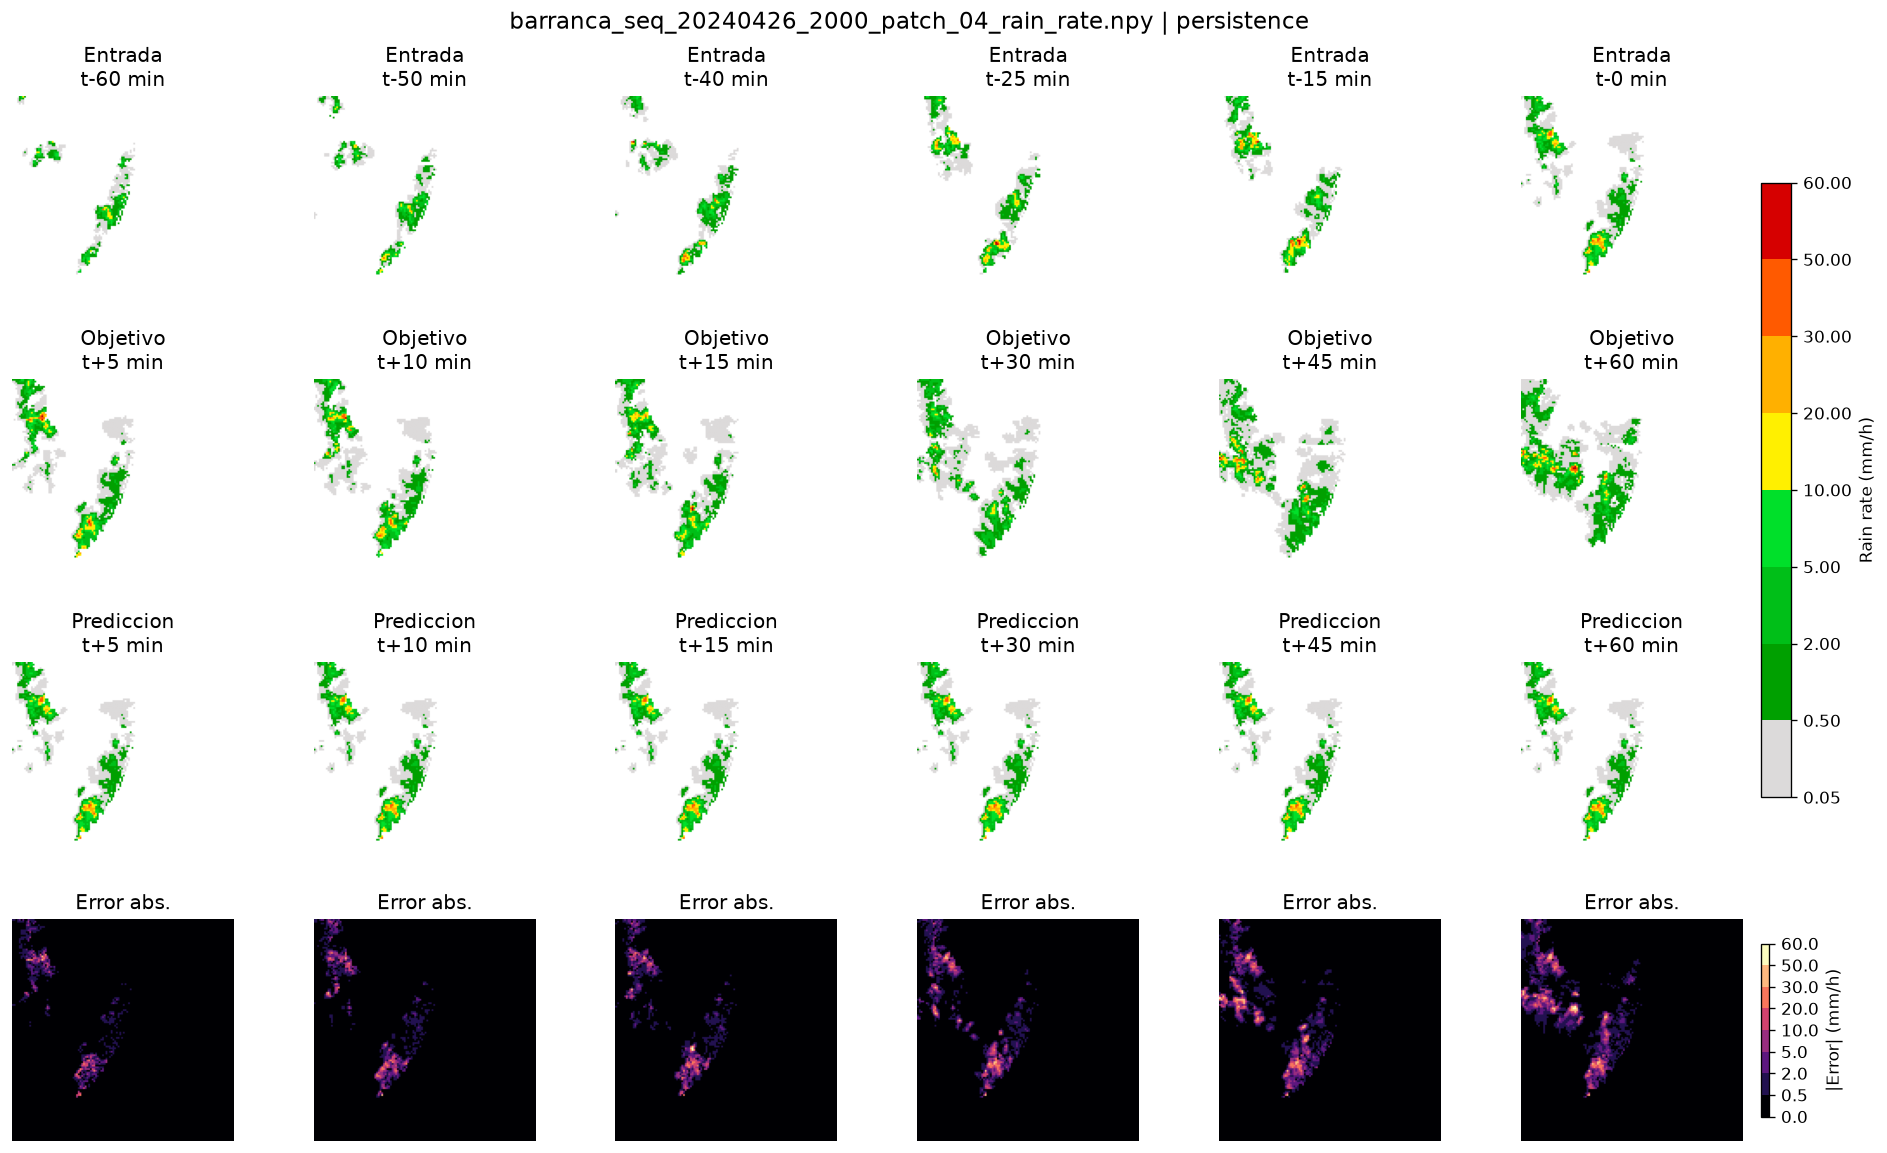

In [6]:
from course_utils.plotting import plot_event_grid
sample_name = SAMPLE_FILES[0]
res = all_results[sample_name]

print(f"Comparación visual para {sample_name} (Persistencia vs Earthformer)")
fig1 = plot_event_grid(res["inputs"], res["target"], res["earthformer"], sample_name, "earthformer")
plt.show()

fig2 = plot_event_grid(res["inputs"], res["target"], res["persistence"], sample_name, "persistence")
plt.show()

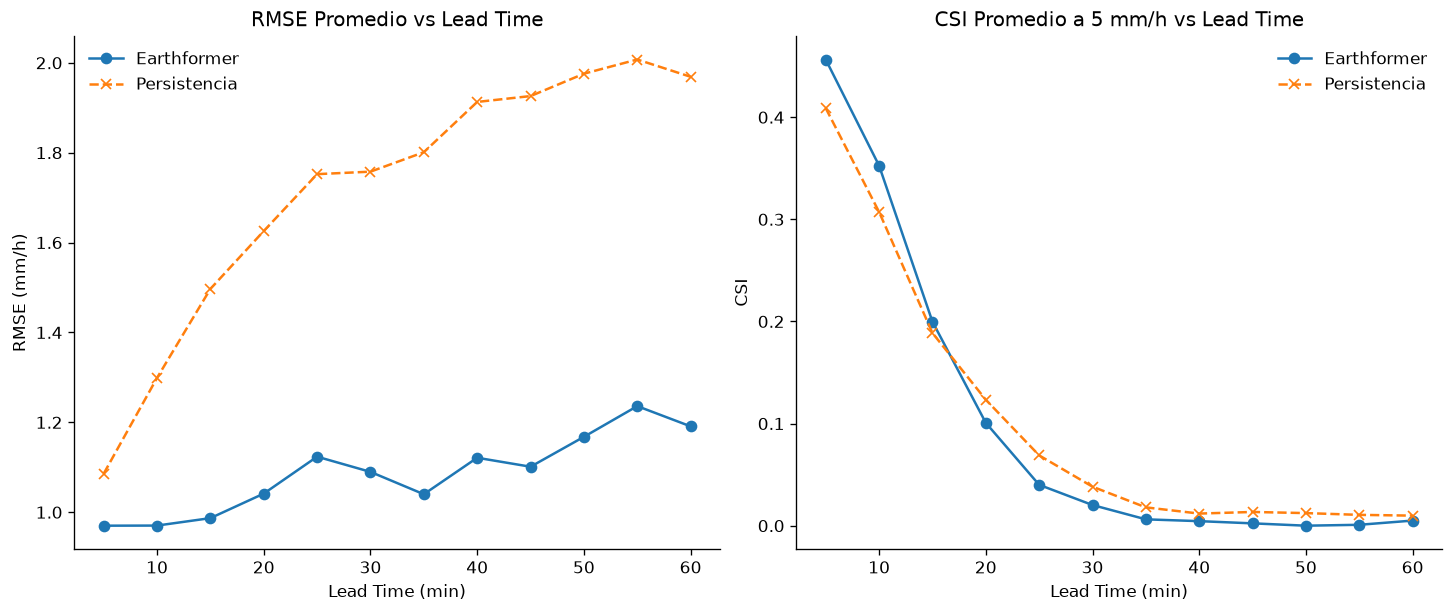

In [7]:
# Comparar RMSE y CSI por lead time promediado entre todos los casos
ef_rmse = []
pers_rmse = []
ef_csi_5 = []
pers_csi_5 = []

for name in SAMPLE_FILES:
    res = all_results[name]
    
    # Earthformer metrics
    ef_c = continuous_metrics(res["earthformer"], res["target"])
    ef_e = event_metrics_by_threshold_and_lead(res["earthformer"], res["target"], THRESHOLDS)
    ef_rmse.append(ef_c["RMSE"].values)
    ef_csi_5.append(ef_e[ef_e["threshold_mm_h"] == 5.0]["CSI"].values)
    
    # Persistence metrics
    pers_c = continuous_metrics(res["persistence"], res["target"])
    pers_e = event_metrics_by_threshold_and_lead(res["persistence"], res["target"], THRESHOLDS)
    pers_rmse.append(pers_c["RMSE"].values)
    pers_csi_5.append(pers_e[pers_e["threshold_mm_h"] == 5.0]["CSI"].values)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axes[0].plot(LEAD_MINUTES, np.mean(ef_rmse, axis=0), marker="o", label="Earthformer")
axes[0].plot(LEAD_MINUTES, np.mean(pers_rmse, axis=0), marker="x", label="Persistencia", linestyle="--")
axes[0].set_title("RMSE Promedio vs Lead Time")
axes[0].set_xlabel("Lead Time (min)")
axes[0].set_ylabel("RMSE (mm/h)")
axes[0].legend()

axes[1].plot(LEAD_MINUTES, np.mean(ef_csi_5, axis=0), marker="o", label="Earthformer")
axes[1].plot(LEAD_MINUTES, np.mean(pers_csi_5, axis=0), marker="x", label="Persistencia", linestyle="--")
axes[1].set_title("CSI Promedio a 5 mm/h vs Lead Time")
axes[1].set_xlabel("Lead Time (min)")
axes[1].set_ylabel("CSI")
axes[1].legend()

plt.show()

## 4. Preguntas de Interpretación Comparativa

### 1. ¿Cómo se comporta visualmente la predicción de Earthformer frente a la Persistencia?
Earthformer muestra una predicción fluida y dinámica donde los núcleos lluviosos se desplazan y disipan en el tiempo, a diferencia de la persistencia que los mantiene congelados en la última posición. Sin embargo, se nota que los contornos de Earthformer se van volviendo más suaves (borrosos) a lead times de 45-60 min.

### 2. ¿La mejora se nota más en métricas continuas (RMSE) o en binarias (CSI)?
La mejora de Earthformer es más marcada en el RMSE en plazos largos (30-60 min) debido al suavizado de la predicción, que reduce el error de distancia. En el CSI de lluvia moderada/fuerte (5 mm/h) también supera a la persistencia en lead times largos ya que modela el desplazamiento físico del sistema convectivo.

### 3. ¿Qué implicancias tiene esto para el pronóstico en tiempo real y la alerta de inundaciones?
El modelado del desplazamiento físico de la tormenta en Earthformer permite prever qué áreas se verán afectadas en los próximos 30-60 minutos, lo que mejora la alerta de inundaciones frente a una persistencia inmóvil. Sin embargo, el suavizado de la intensidad máxima requiere precaución porque puede atenuar la severidad real del evento.